<a href="https://colab.research.google.com/github/Zachos-K/-/blob/main/01_bank_marketing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Big Data & Data Mining Project
## Bank Marketing Dataset - End-to-End Data Mining System

**Στόχος:** Υλοποίηση ολοκληρωμένου συστήματος ανάλυσης δεδομένων που περιλαμβάνει:
- Data Understanding & Preprocessing
- Exploratory Data Analysis
- Classification Models
- Advanced Technique: K-Means Clustering
- Big Data Approach με PySpark
- Model Evaluation & Συμπεράσματα

**Ομάδα:**
- Ζαχαρίας Κυριακέας (22390114)
 - Data Engineer
 - Data Analyst
 - ML Engineer

**Dataset:** Bank Marketing Dataset

**Classification target:** Πρόβλεψη του αν ένας πελάτης θα εγγραφεί σε προθεσμιακή κατάθεση (`y`: yes/no).

## 1. Setup & Imports

Σε αυτό το στάδιο φορτώνουμε τις απαραίτητες βιβλιοθήκες. Το notebook είναι οργανωμένο ώστε να δημιουργεί και τους φακέλους εξόδου για γραφήματα και αποτελέσματα.

In [1]:
import os
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Dataset Download / Loading



In [8]:
import os
import pandas as pd

DATA_PATH = "/content/bank-additional-full.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, sep=";")
    print("Dataset loaded successfully!")
    print("Shape:", df.shape)
    display(df.head())
else:
    print("Δεν βρέθηκε το αρχείο:", DATA_PATH)
    print("Τα αρχεία που υπάρχουν στο /content είναι:")
    print(os.listdir("/content"))

Dataset loaded successfully!
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Data Understanding

Εξετάζουμε το μέγεθος του dataset, τους τύπους μεταβλητών, βασικά στατιστικά και την κατανομή της μεταβλητής στόχου.

In [9]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include="all").T)

Shape: (41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.id

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Missing values ανά στήλη:")
display(df.isnull().sum())

print("\nTarget distribution:")
display(df["y"].value_counts())
display(df["y"].value_counts(normalize=True).rename("proportion"))

Missing values ανά στήλη:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Target distribution:


,count
y,
no,36548
yes,4640


,proportion
y,
no,0.887346
yes,0.112654


### Σημείωση για data leakage

Η μεταβλητή `duration` αφαιρείται από το predictive modeling, γιατί είναι γνωστή μόνο μετά την ολοκλήρωση της τηλεφωνικής κλήσης. Αν χρησιμοποιηθεί, το μοντέλο μπορεί να έχει τεχνητά υψηλή απόδοση, χωρίς να είναι ρεαλιστικό για πραγματική πρόβλεψη πριν ή κατά τον σχεδιασμό της καμπάνιας.

## 4. Data Cleaning & Feature Engineering

Βήματα:
1. Μετατροπή target `y` σε δυαδική μεταβλητή `target`.
2. Αφαίρεση `duration` για αποφυγή data leakage.
3. Δημιουργία νέων χαρακτηριστικών όπως ηλικιακή ομάδα και ένδειξη προηγούμενης επικοινωνίας.
4. Διατήρηση της τιμής `unknown` ως ειδικής κατηγορίας, επειδή μπορεί να περιέχει πληροφορία.

In [11]:
df_model = df.copy()

# Target encoding
df_model["target"] = df_model["y"].map({"no": 0, "yes": 1})
df_model = df_model.drop(columns=["y"])

# Drop duration to avoid leakage
if "duration" in df_model.columns:
    df_model = df_model.drop(columns=["duration"])

# Feature engineering
if "age" in df_model.columns:
    df_model["age_group"] = pd.cut(
        df_model["age"],
        bins=[0, 30, 45, 60, 100],
        labels=["young", "adult", "middle", "senior"]
    )

if "pdays" in df_model.columns:
    # In bank-additional-full.csv, 999 means not previously contacted
    df_model["was_contacted_before"] = np.where(df_model["pdays"] == 999, 0, 1)

if "campaign" in df_model.columns:
    df_model["many_contacts"] = np.where(df_model["campaign"] > df_model["campaign"].median(), 1, 0)

print(df_model.shape)
display(df_model.head())

(41188, 23)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target,age_group,was_contacted_before,many_contacts
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,middle,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,middle,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,adult,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,adult,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,middle,0,0


### Outlier Handling

Για τις αριθμητικές μεταβλητές εφαρμόζεται IQR clipping, ώστε ακραίες τιμές να μην επηρεάζουν υπερβολικά τα μοντέλα που βασίζονται σε απόσταση ή κλίμακα.

In [12]:
numeric_cols_all = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols_all = [c for c in numeric_cols_all if c != "target"]

def clip_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        data[col] = data[col].clip(lower, upper)
    return data

df_model = clip_outliers_iqr(df_model, numeric_cols_all)
df_model.to_csv("../data/processed/bank_cleaned.csv", index=False)
print("Saved processed data to ../data/processed/bank_cleaned.csv")

Saved processed data to ../data/processed/bank_cleaned.csv


## 5. Exploratory Data Analysis (EDA)

Στόχος του EDA είναι να κατανοηθεί η κατανομή των μεταβλητών και να εντοπιστούν patterns που σχετίζονται με την πιθανότητα εγγραφής σε προθεσμιακή κατάθεση.

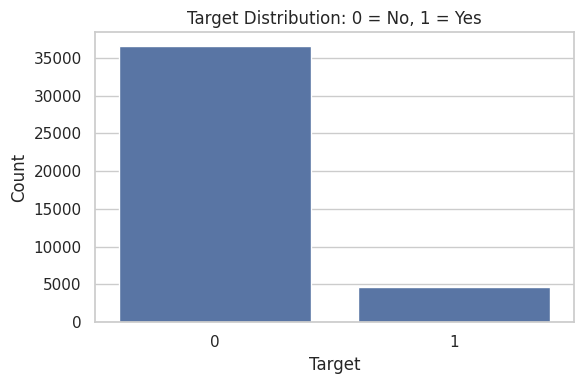

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_model, x="target")
plt.title("Target Distribution: 0 = No, 1 = Yes")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/target_distribution.png", dpi=200)
plt.show()

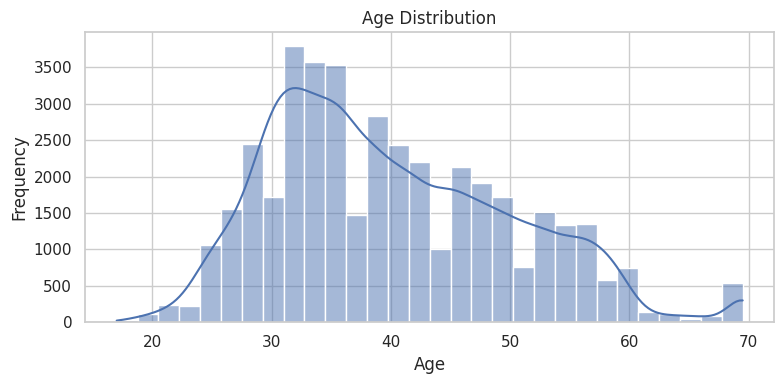

In [14]:
if "age" in df_model.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_model["age"], bins=30, kde=True)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("../outputs/figures/age_distribution.png", dpi=200)
    plt.show()

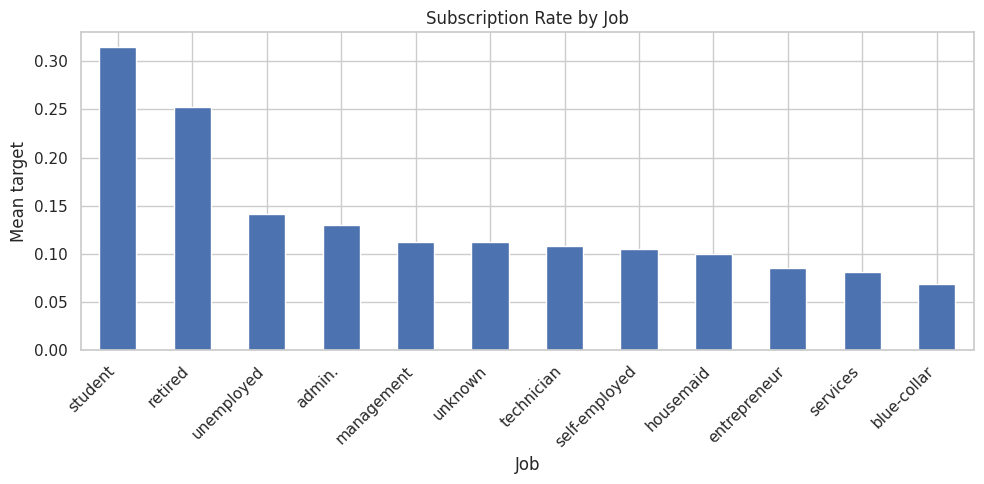

In [15]:
if "job" in df_model.columns:
    job_success = df_model.groupby("job")["target"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    job_success.plot(kind="bar")
    plt.title("Subscription Rate by Job")
    plt.ylabel("Mean target")
    plt.xlabel("Job")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("../outputs/figures/subscription_rate_by_job.png", dpi=200)
    plt.show()

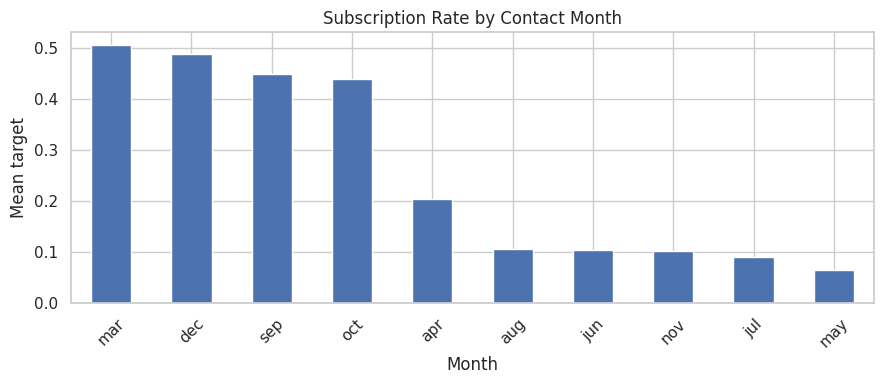

In [16]:
if "month" in df_model.columns:
    month_success = df_model.groupby("month")["target"].mean().sort_values(ascending=False)
    plt.figure(figsize=(9,4))
    month_success.plot(kind="bar")
    plt.title("Subscription Rate by Contact Month")
    plt.ylabel("Mean target")
    plt.xlabel("Month")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("../outputs/figures/subscription_rate_by_month.png", dpi=200)
    plt.show()

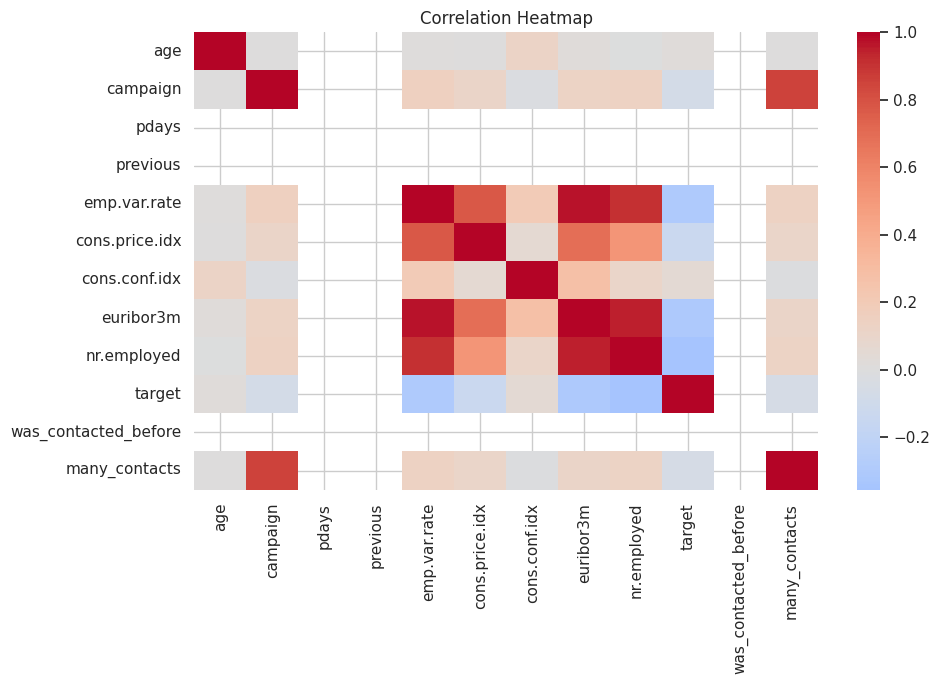

In [17]:
plt.figure(figsize=(10,7))
corr = df_model.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=200)
plt.show()

## 6. Train-Test Split & Preprocessing Pipeline

Οι κατηγορικές μεταβλητές μετατρέπονται με One-Hot Encoding και οι αριθμητικές μεταβλητές κανονικοποιούνται με StandardScaler. Η διάσπαση σε train/test γίνεται με stratification, ώστε να διατηρηθεί η αναλογία των κλάσεων.

In [19]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Train shape: (32950, 22)
Test shape: (8238, 22)
Numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'many_contacts']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group']


## 7. Classification Models

Υλοποιούνται περισσότερα από δύο μοντέλα ταξινόμησης ώστε να γίνει ουσιαστική σύγκριση:
- Decision Tree
- Linear SVM
- Naive Bayes
- Neural Network / MLP

In [26]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(32, 16),
        max_iter=120,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

## 8. Model Evaluation

Χρησιμοποιούμε Accuracy, Precision, Recall, F1-score, Confusion Matrix και ROC-AUC. Επειδή το dataset έχει ανισορροπία στις κλάσεις, το F1-score και το ROC-AUC είναι πιο χρήσιμα από το απλό Accuracy.


Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



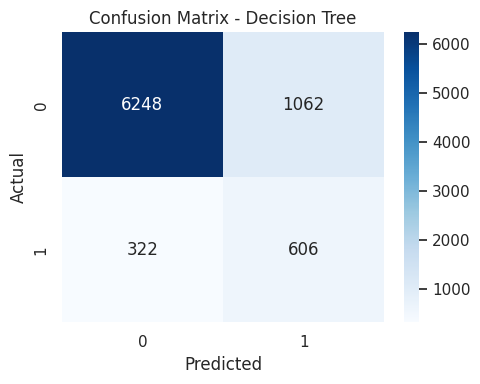

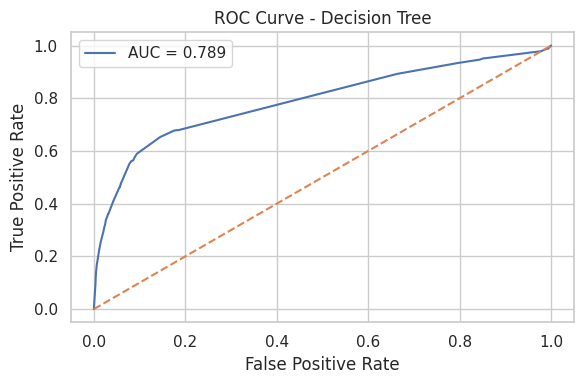


Linear SVM
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



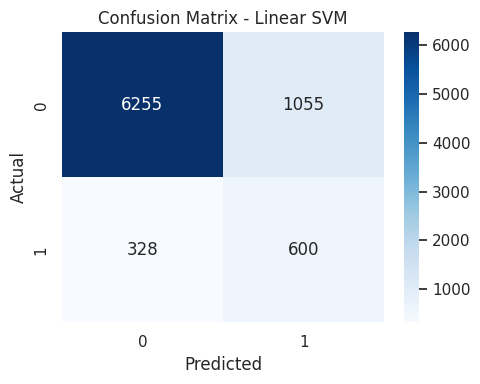

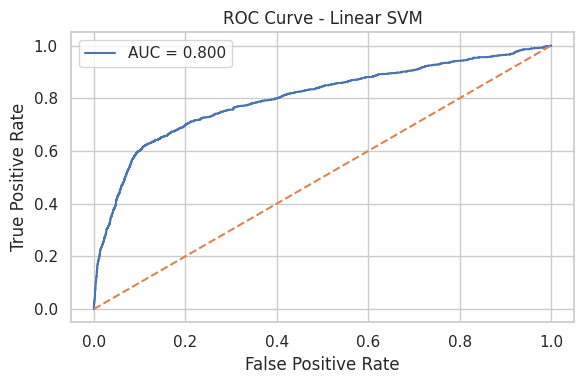


Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7310
           1       0.32      0.66      0.43       928

    accuracy                           0.80      8238
   macro avg       0.63      0.74      0.65      8238
weighted avg       0.88      0.80      0.83      8238



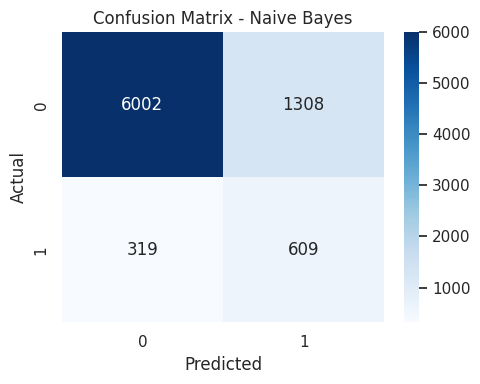

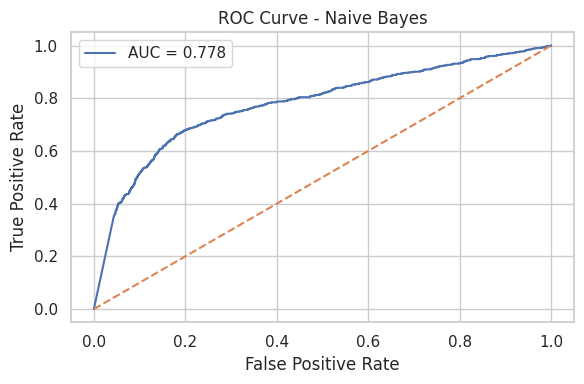


Neural Network
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.67      0.23      0.34       928

    accuracy                           0.90      8238
   macro avg       0.79      0.61      0.64      8238
weighted avg       0.88      0.90      0.88      8238



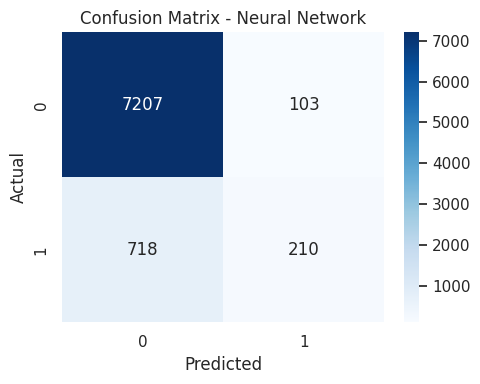

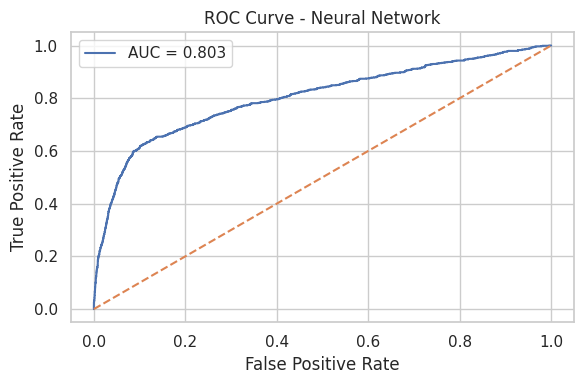

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.831998,0.363309,0.653017,0.466872,0.789248
1,Linear SVM,0.832119,0.362538,0.646552,0.464576,0.800495
2,Naive Bayes,0.802501,0.317684,0.656250,0.428120,0.778497
3,Neural Network,0.900340,0.670927,0.226293,0.338437,0.802866


In [21]:
results = []
trained_pipelines = {}

def evaluate_model(name, model):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline.named_steps["model"], "decision_function"):
        y_score = pipeline.decision_function(X_test)
    else:
        y_score = y_pred

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }
    results.append(metrics)
    trained_pipelines[name] = pipeline

    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"../outputs/figures/confusion_matrix_{safe_name}.png", dpi=200)
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['ROC-AUC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/roc_curve_{safe_name}.png", dpi=200)
    plt.show()

    return pipeline

for model_name, model in models.items():
    evaluate_model(model_name, model)

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
results_df.to_csv("../outputs/metrics/model_results.csv", index=False)
display(results_df)

## 9. Model Comparison

Το καλύτερο μοντέλο επιλέγεται κυρίως με βάση το F1-score και το ROC-AUC. Το Accuracy από μόνο του δεν είναι αρκετό, διότι η κλάση `yes` είναι μικρότερη από την κλάση `no`.

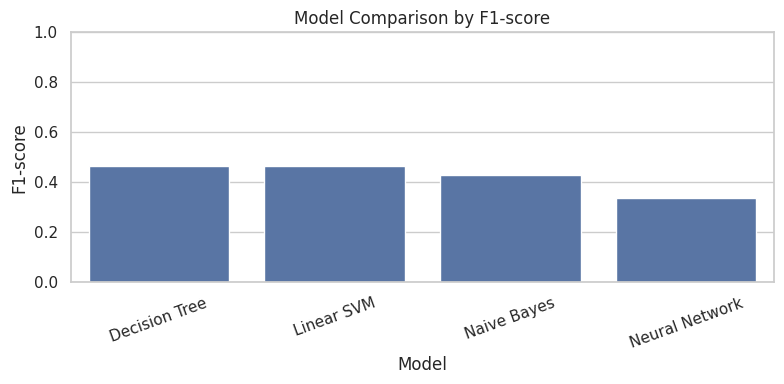

Best model based on F1-score:


,0
Model,Decision Tree
Accuracy,0.831998
Precision,0.363309
Recall,0.653017
F1-score,0.466872
ROC-AUC,0.789248


In [22]:
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="F1-score")
plt.title("Model Comparison by F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison_f1.png", dpi=200)
plt.show()

best_model = results_df.iloc[0]
print("Best model based on F1-score:")
display(best_model)

## 10. Advanced Technique: K-Means Clustering

Χρησιμοποιούμε K-Means για τμηματοποίηση πελατών σε ομάδες με παρόμοια χαρακτηριστικά. Στη συνέχεια συγκρίνουμε τα clusters ως προς το ποσοστό εγγραφής.

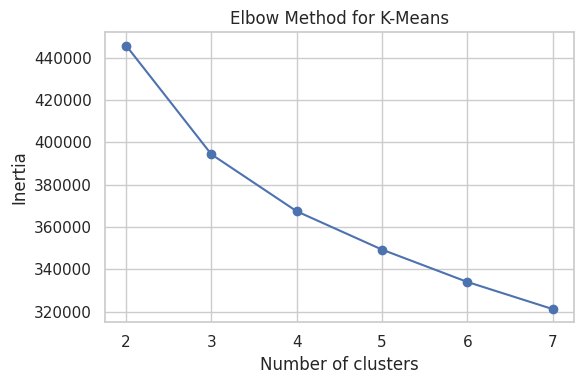

In [23]:
X_cluster = df_model.drop(columns=["target"])
X_cluster_processed = preprocessor.fit_transform(X_cluster)

inertias = []
k_range = range(2, 8)
for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_tmp.fit(X_cluster_processed)
    inertias.append(kmeans_tmp.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_elbow.png", dpi=200)
plt.show()

,cluster,count,subscription_rate
0,0,18066,0.048932
1,1,13499,0.244537
2,2,9623,0.047283


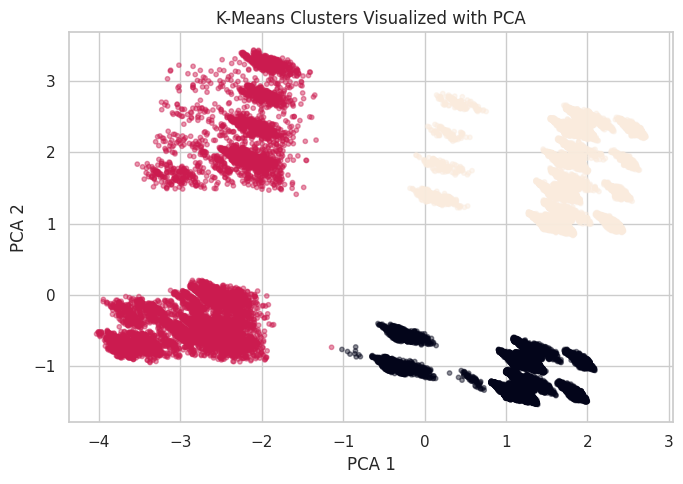

In [27]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
df_model["cluster"] = kmeans.fit_predict(X_cluster_processed)

cluster_summary = df_model.groupby("cluster").agg(
    count=("target", "size"),
    subscription_rate=("target", "mean")
).reset_index()

display(cluster_summary)
cluster_summary.to_csv("../outputs/metrics/cluster_summary.csv", index=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_processed)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_model["cluster"], alpha=0.45, s=10)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_pca_clusters.png", dpi=200)
plt.show()

## 11. Big Data Approach with PySpark

Η παρακάτω ενότητα δείχνει πώς μπορεί να υλοποιηθεί παρόμοιο pipeline με PySpark.

In [30]:
!pip install pyspark -q

import os
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder as SparkOneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

possible_paths = [
    "/content/bank-additional-full.csv",
    "bank-additional-full.csv",
    "../data/raw/bank-additional-full.csv",
    "../data/bank-additional-full.csv"
]

SPARK_DATA_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        SPARK_DATA_PATH = path
        break

if SPARK_DATA_PATH is None:
    raise FileNotFoundError("Δεν βρέθηκε το bank-additional-full.csv. Ανέβασέ το πρώτα στο Colab.")

print("Spark dataset path:", SPARK_DATA_PATH)

# Δημιουργία Spark Session
spark = SparkSession.builder \
    .appName("BankMarketingBigDataProject") \
    .getOrCreate()

# Φόρτωση CSV
spark_df = spark.read.csv(
    SPARK_DATA_PATH,
    header=True,
    inferSchema=True,
    sep=";"
)

print("Initial Spark columns:")
print(spark_df.columns)

# Μετονομασία στηλών για να φύγουν οι τελείες
# π.χ. emp.var.rate -> emp_var_rate
for old_col in spark_df.columns:
    new_col = old_col.replace(".", "_")
    spark_df = spark_df.withColumnRenamed(old_col, new_col)

print("Renamed Spark columns:")
print(spark_df.columns)

# Αφαίρεση duration για αποφυγή data leakage
if "duration" in spark_df.columns:
    spark_df = spark_df.drop("duration")
    print("Η στήλη duration αφαιρέθηκε.")

# Εμφάνιση πρώτων γραμμών και schema
spark_df.show(5)
spark_df.printSchema()

# Μεταβλητή στόχος
label_indexer = StringIndexer(
    inputCol="y",
    outputCol="label",
    handleInvalid="skip"
)

# Κατηγορικές μεταβλητές
categorical_cols_spark = [
    field.name for field in spark_df.schema.fields
    if str(field.dataType) == "StringType()" and field.name != "y"
]

# Αριθμητικές μεταβλητές
numeric_cols_spark = [
    field.name for field in spark_df.schema.fields
    if str(field.dataType) != "StringType()" and field.name != "y"
]

print("Categorical columns:", categorical_cols_spark)
print("Numeric columns:", numeric_cols_spark)

# StringIndexer για κατηγορικές μεταβλητές
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categorical_cols_spark
]

# One-Hot Encoding
encoders = [
    SparkOneHotEncoder(
        inputCol=col + "_index",
        outputCol=col + "_encoded"
    )
    for col in categorical_cols_spark
]

# Όλες οι τελικές μεταβλητές εισόδου
feature_cols = numeric_cols_spark + [
    col + "_encoded" for col in categorical_cols_spark
]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

# Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=6,
    seed=42
)

# Spark ML Pipeline
spark_pipeline = SparkPipeline(
    stages=[label_indexer] + indexers + encoders + [assembler, rf]
)

# Train-test split
train_data, test_data = spark_df.randomSplit([0.8, 0.2], seed=42)

# Εκπαίδευση
spark_model = spark_pipeline.fit(train_data)

# Προβλέψεις
predictions = spark_model.transform(test_data)

# Evaluation
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

spark_auc = auc_evaluator.evaluate(predictions)
spark_accuracy = accuracy_evaluator.evaluate(predictions)
spark_f1 = f1_evaluator.evaluate(predictions)

spark_results = pd.DataFrame([{
    "Model": "Spark Random Forest",
    "Accuracy": spark_accuracy,
    "F1-score": spark_f1,
    "ROC-AUC": spark_auc
}])

display(spark_results)

# Αποθήκευση αποτελεσμάτων
os.makedirs("/content/outputs/metrics", exist_ok=True)
spark_results.to_csv("/content/outputs/metrics/spark_results.csv", index=False)

# Εμφάνιση προβλέψεων
predictions.select("label", "prediction", "probability").show(5)

Spark dataset path: /content/bank-additional-full.csv
Initial Spark columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Renamed Spark columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']
Η στήλη duration αφαιρέθηκε.
+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+-----+--------+-----------+------------+--------------+-------------+---------+-----------+---+
|age|      job|marital|  education|default|housing|loan|  contact|month|day_of_week|campaign|pdays|previous|   poutcome|emp_var_rate|cons_price_idx|cons_conf_idx|euribor3m|nr_employed|  y|
+--

,Model,Accuracy,F1-score,ROC-AUC
0,Spark Random Forest,0.899525,0.871702,0.796055


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.90495525882293...|
|  0.0|       0.0|[0.85743042040517...|
|  1.0|       0.0|[0.85743042040517...|
|  0.0|       0.0|[0.85499138383776...|
|  0.0|       0.0|[0.85525970169121...|
+-----+----------+--------------------+
only showing top 5 rows
